# Logika rozmyta - gra w kółko i krzyżyk



In [1]:
from simpful import FuzzySystem

FS = FuzzySystem(show_banner=False)

## Zmienne wejściowe

Zdefiniujemy 4 zmienne wejściowe (po 3 funkcje członkostwa) oraz później 1 zmienną wyjściową (zawierającą 4 funkcje członkostwa). Będą to kolejno: 
- `opportunity`: szansa na wygraną ($0$: brak, $1$: ruch wygrywający)
- `threat`: zagrożenie ze strony przeciwnika ($0$: brak, $1$: przeciwnik wygrywa w następnym ruchu)
- `board_position`: strategiczna wartość pola ($0$: boki, $0.5$: rogi, $1$: środek)
- `game_phase`: etap gry ($0-9$: numer ruchu)

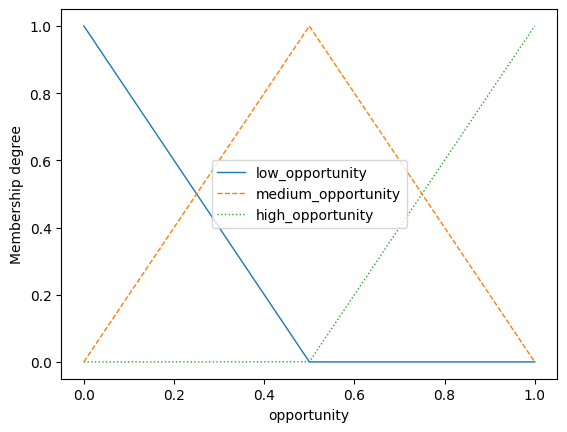

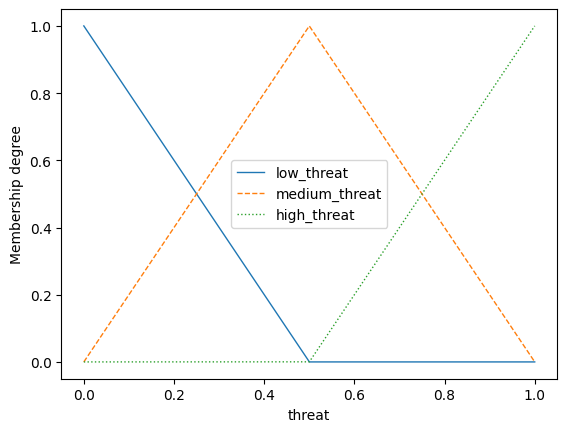

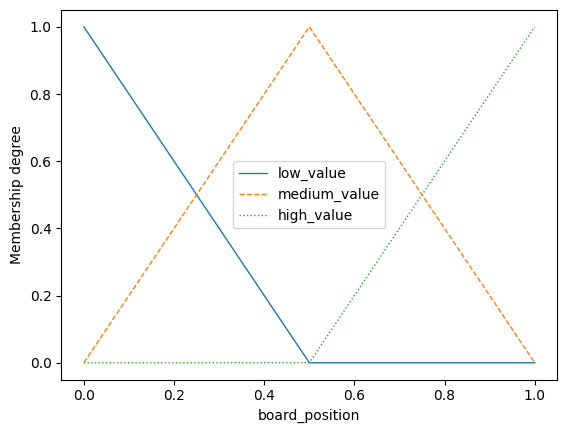

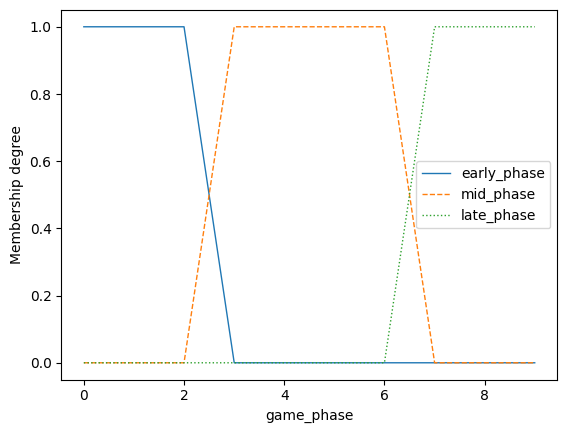

In [2]:
from simpful import TriangleFuzzySet, TrapezoidFuzzySet, LinguisticVariable

o_1 = TriangleFuzzySet(0.0, 0.0, 0.5, term="low_opportunity")
o_2 = TriangleFuzzySet(0.0, 0.5, 1.0, term="medium_opportunity")
o_3 = TriangleFuzzySet(0.5, 1.0, 1.0, term="high_opportunity")
FS.add_linguistic_variable(
    "opportunity",
    LinguisticVariable([o_1, o_2, o_3], universe_of_discourse=[0.0, 1.0]),
)
FS.plot_variable("opportunity")

t_1 = TriangleFuzzySet(0.0, 0.0, 0.5, term="low_threat")
t_2 = TriangleFuzzySet(0.0, 0.5, 1.0, term="medium_threat")
t_3 = TriangleFuzzySet(0.5, 1.0, 1.0, term="high_threat")
FS.add_linguistic_variable(
    "threat",
    LinguisticVariable([t_1, t_2, t_3], universe_of_discourse=[0.0, 1.0]),
)
FS.plot_variable("threat")

p_1 = TriangleFuzzySet(0.0, 0.0, 0.5, term="low_value")
p_2 = TriangleFuzzySet(0.0, 0.5, 1.0, term="medium_value")
p_3 = TriangleFuzzySet(0.5, 1.0, 1.0, term="high_value")
FS.add_linguistic_variable(
    "board_position",
    LinguisticVariable([p_1, p_2, p_3], universe_of_discourse=[0.0, 1.0]),
)
FS.plot_variable("board_position")

g_1 = TrapezoidFuzzySet(0, 0, 2, 3, term="early_phase")
g_2 = TrapezoidFuzzySet(2, 3, 6, 7, term="mid_phase")
g_3 = TrapezoidFuzzySet(6, 7, 9, 9, term="late_phase")
FS.add_linguistic_variable(
    "game_phase",
    LinguisticVariable([g_1, g_2, g_3], universe_of_discourse=[0, 9]),
)
FS.plot_variable("game_phase")

## Zmienna wyjściowa
Jako `move_priority` oznaczamy priorytet (wartość) postawienia znaku na danym polu w zakresie od $0$ do $1$.

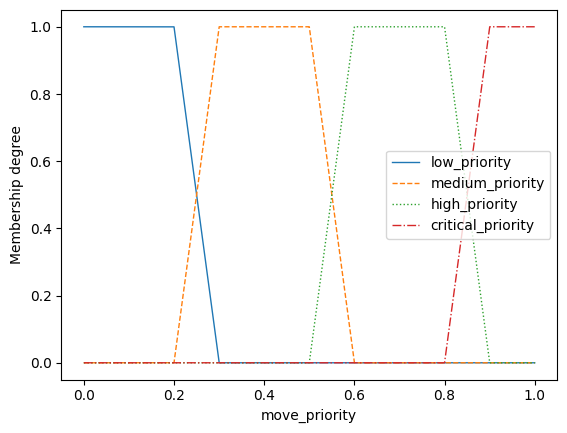

In [3]:
mp_1 = TrapezoidFuzzySet(0.0, 0.0, 0.2, 0.3, term="low_priority")
mp_2 = TrapezoidFuzzySet(0.2, 0.3, 0.5, 0.6, term="medium_priority")
mp_3 = TrapezoidFuzzySet(0.5, 0.6, 0.8, 0.9, term="high_priority")
mp_4 = TrapezoidFuzzySet(0.8, 0.9, 1.0, 1.0, term="critical_priority")
FS.add_linguistic_variable(
    "move_priority",
    LinguisticVariable([mp_1, mp_2, mp_3, mp_4], universe_of_discourse=[0.0, 1.0]),
)
FS.plot_variable("move_priority")

## Reguły wnioskowania

Stworzymy 9 reguł wnioskowania dobranych na podstawie manualnych testów oraz intuicji.

In [4]:
FS.add_rules(
    [
        # if you can win
        "IF (opportunity IS high_opportunity) THEN (move_priority IS critical_priority)",
        # if opponent can win next turn
        "IF (threat IS high_threat) THEN (move_priority IS high_priority)",
        # center opening move
        "IF (game_phase IS early_phase) AND (board_position IS high_value) THEN (move_priority IS high_priority)",
        # corners opening move
        "IF (game_phase IS early_phase) AND (board_position IS medium_value) THEN (move_priority IS medium_priority)",
        # sides opening move
        "IF (game_phase IS early_phase) AND (board_position IS low_value) THEN (move_priority IS low_priority)",
        # neutralize medium threat
        "IF (threat IS medium_threat) AND (opportunity IS medium_opportunity) THEN (move_priority IS medium_priority)",
        "IF (threat IS medium_threat) AND (opportunity IS low_opportunity) THEN (move_priority IS low_priority)",
        # weak move
        "IF (threat IS low_threat) THEN (move_priority IS low_priority)",
        "IF (opportunity IS low_opportunity) THEN (move_priority IS low_priority)",
    ]
)

## Funkcje pomocnicze

Zaimplementujemy funkcje służące do automatycznego podawania danych wejściowych oraz wyświetlania wyników na podstawie wnioskowania.

In [5]:
def get_move_priorities(board, bot_symbol):
    """Calulates priorities for all free cells."""
    opp_symbol = "O" if bot_symbol == "X" else "X"
    moves_made = sum(cell != " " for row in board for cell in row)

    # predefined strategic values (center, corners, edges)
    POS_VALUES = (
        (0.5, 0.1, 0.5),
        (0.1, 1.0, 0.1),
        (0.5, 0.1, 0.5),
    )

    def eval_line(line, player, enemy):
        if enemy in line:
            return 0.0

        player_count = line.count(player)
        if player_count == 2:
            return 1.0
        elif player_count == 1:
            return 0.5
        else:
            return 0.0

    priorities_map = {}
    for i in range(3):
        for j in range(3):
            if board[i][j] != " ":
                continue  # skip occupied cells

            pos_val = POS_VALUES[i][j]

            # gather all lines (row, column, diagonals) that intersect with cell (i, j)
            lines = [board[i], [board[i][j] for i in range(3)]]
            if i == j:
                lines.append([board[i][i] for i in range(3)])
            if i + j == 2:
                lines.append([board[i][2 - i] for i in range(3)])

            # evalute max opportunity and threat across all lines for this cell
            max_opp = max(eval_line(line, bot_symbol, opp_symbol) for line in lines)
            max_thr = max(eval_line(line, opp_symbol, bot_symbol) for line in lines)

            # pass variables to fuzzy system
            FS.set_variable("opportunity", max_opp)
            FS.set_variable("threat", max_thr)
            FS.set_variable("board_position", pos_val)
            FS.set_variable("game_phase", moves_made)

            priorities_map[(i, j)] = {
                "priority": FS.inference()["move_priority"],
                "opportunity": max_opp,
                "threat": max_thr,
                "board_position": pos_val,
                "game_phase": moves_made,
            }

    return priorities_map


def display_priority_board(board, bot_symbol):
    """Displays the board with move priorities for the bot's next move."""
    priorities = get_move_priorities(board, bot_symbol)

    print(f"Variables for each valid move (Playing as {bot_symbol}):")
    for (i, j), data in priorities.items():
        opportunity = data["opportunity"]
        threat = data["threat"]
        board_position = data["board_position"]
        game_phase = data["game_phase"]
        priority = data["priority"]
        print(
            f"Cell ({i},{j}) [{priority:.4f}] -> ",
            f"{opportunity=}, ",
            f"{threat=}, ",
            f"{board_position=}, ",
            f"{game_phase=}",
        )

    print("\nPriority Board:")
    print("+------+------+------+")
    for i in range(3):
        print("|", end="")
        for j in range(3):
            cell_value = board[i][j]
            if cell_value != " ":
                print(f"{cell_value:^6}|", end="")
            else:
                priority = priorities.get((i, j), {}).get("priority", 0.0)
                print(f"{priority:.4f}|", end="")
        print("\n+------+------+------+")

## Przykładowe działanie dla danej planszy

In [6]:
test_board = [
    [" ", " ", "O"],
    [" ", "X", " "],
    [" ", " ", " "],
]

display_priority_board(test_board, "X")

Variables for each valid move (Playing as X):
Cell (0,0) [0.4000] ->  opportunity=0.5,  threat=0.5,  board_position=0.5,  game_phase=2
Cell (0,1) [0.2917] ->  opportunity=0.5,  threat=0.5,  board_position=0.1,  game_phase=2
Cell (1,0) [0.1870] ->  opportunity=0.5,  threat=0.0,  board_position=0.1,  game_phase=2
Cell (1,2) [0.2917] ->  opportunity=0.5,  threat=0.5,  board_position=0.1,  game_phase=2
Cell (2,0) [0.2767] ->  opportunity=0.0,  threat=0.0,  board_position=0.5,  game_phase=2
Cell (2,1) [0.1870] ->  opportunity=0.5,  threat=0.0,  board_position=0.1,  game_phase=2
Cell (2,2) [0.4000] ->  opportunity=0.5,  threat=0.5,  board_position=0.5,  game_phase=2

Priority Board:
+------+------+------+
|0.4000|0.2917|  O   |
+------+------+------+
|0.1870|  X   |0.2917|
+------+------+------+
|0.2767|0.1870|0.4000|
+------+------+------+
